In [1]:
import pandas as pd
import re
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../src"))
if project_root not in sys.path:
    sys.path.append(project_root)

from visualization import *

In [2]:
data_loc = r'/Users/novak/Library/CloudStorage/GoogleDrive-hc3429@columbia.edu/Shared drives/Turi_lab/Data/PTSD_project/DLC_and_Moseq/sefl_1s_bout/2025_02_06-09_35_01/stats_df_cond_age.csv'
kpms_data = pd.read_csv(data_loc)

In [3]:
kpms_data

,group,name,syllable,heading_mean,heading_std,heading_min,heading_max,angular_velocity_mean,angular_velocity_std,angular_velocity_min,angular_velocity_max,velocity_px_s_mean,velocity_px_s_std,velocity_px_s_min,velocity_px_s_max,frequency,duration
0,control and old,ptsd5_recall1_06DLC_resnet50_phi_cfc_boxNov7sh...,0,-1.855623,1.080461,-3.140100,3.130117,0.179777,1.564614,-3.962133,4.417604,61.023097,44.765041,2.411511,350.934006,0.406250,3.630769
1,control and old,ptsd5_recall1_06DLC_resnet50_phi_cfc_boxNov7sh...,1,-2.206138,0.462365,-2.911298,-1.376281,0.006980,0.721779,-2.359913,1.830727,23.044742,13.186910,0.000000,60.166116,0.156250,1.786667
2,control and old,ptsd5_recall1_06DLC_resnet50_phi_cfc_boxNov7sh...,2,-1.041603,0.242288,-1.324353,-0.731865,-1.787462,0.465829,-2.298700,-0.901721,84.840601,52.738781,3.664594,162.029921,0.031250,0.933333
3,control and old,ptsd5_recall1_06DLC_resnet50_phi_cfc_boxNov7sh...,5,-2.316737,0.433328,-2.728502,-1.409966,-0.055897,0.515612,-2.154003,1.439773,22.962039,12.342523,2.581726,56.503563,0.093750,5.466667
4,control and old,ptsd5_recall1_06DLC_resnet50_phi_cfc_boxNov7sh...,7,-2.676036,0.190882,-2.836662,-2.327033,0.132700,1.290470,-1.864662,1.600124,43.069682,25.326186,6.143768,92.397708,0.031250,1.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2032,sefl and young,ptsd6_recall4_75DLC_resnet50_phi_cfc_boxNov7sh...,14,0.197636,1.515043,-1.160597,1.779852,-2.212848,1.778027,-4.832867,0.857323,167.689511,76.125876,40.619186,259.996870,0.010582,1.466667
2033,sefl and young,ptsd6_recall4_75DLC_resnet50_phi_cfc_boxNov7sh...,15,-1.548294,0.959578,-2.881870,-0.077436,-2.080117,35.586025,-182.452020,13.565589,124.715482,49.123450,34.907277,218.365528,0.026455,1.493333
2034,sefl and young,ptsd6_recall4_75DLC_resnet50_phi_cfc_boxNov7sh...,16,-1.252862,1.083830,-2.972216,1.914881,6.194237,46.668755,-38.342213,182.295035,148.470012,56.048180,42.054688,231.019249,0.052910,0.773333
2035,sefl and young,ptsd6_recall4_75DLC_resnet50_phi_cfc_boxNov7sh...,17,-0.805985,0.636446,-2.152571,-0.255059,-0.922424,2.200735,-6.650807,1.124158,148.100741,35.052366,97.927591,225.847816,0.021164,1.200000


In [4]:
def extract_cohort_and_day(name: str):
    match2 = re.match(r"(\w+)_([a-zA-Z]+\d*)_(\d+)-(\d+)DLC", name)
    match1 = re.match(r"(\w+)_([a-zA-Z]+\d*)_(\d+)DLC", name)
    if match2:
        cohort_prefix = match2.group(1)
        day = match2.group(2)
        cohort_id = f"{cohort_prefix}_{match2.group(3)}-{match2.group(4)}"
    elif match1:
        cohort_prefix = match1.group(1)
        day = match1.group(2)
        cohort_id = f"{cohort_prefix}_{match1.group(3)}"
    else:
        cohort_id = "unknown"
        day = "unknown"
    return pd.Series([cohort_id, day])

kpms_data['condition'] = kpms_data['group'].str.split(' ').str[0]
kpms_data['age'] = kpms_data['group'].str.split(' ').str[2]
kpms_data[['cohort_id', 'day']] = kpms_data['name'].apply(extract_cohort_and_day)
kpms_data.drop(columns=['name', 'group'], inplace=True)

syllable_map = {
    0: 'scanning 1', 11: 'scanning 2', 12: 'scanning 3',
    1: 'freezing 1', 5: 'freezing 2', 8: 'freezing 3', 14: 'freezing 4',
    2: 'exploring 1', 4: 'exploring 2', 6: 'exploring 3',
    7: 'exploring 4', 9: 'exploring 5', 15: 'exploring 6',
    10: 'locomotion 1', 16: 'locomotion 2', 17: 'locomotion 3', 18: 'locomotion 4',
    3: 'random 1', 13: 'random 2'
}
kpms_data['syllable_name'] = kpms_data['syllable'].map(syllable_map)

In [5]:
kpms_data

,syllable,heading_mean,heading_std,heading_min,heading_max,angular_velocity_mean,angular_velocity_std,angular_velocity_min,angular_velocity_max,velocity_px_s_mean,velocity_px_s_std,velocity_px_s_min,velocity_px_s_max,frequency,duration,condition,age,cohort_id,day,syllable_name
0,0,-1.855623,1.080461,-3.140100,3.130117,0.179777,1.564614,-3.962133,4.417604,61.023097,44.765041,2.411511,350.934006,0.406250,3.630769,control,old,ptsd5_06,recall1,scanning 1
1,1,-2.206138,0.462365,-2.911298,-1.376281,0.006980,0.721779,-2.359913,1.830727,23.044742,13.186910,0.000000,60.166116,0.156250,1.786667,control,old,ptsd5_06,recall1,freezing 1
2,2,-1.041603,0.242288,-1.324353,-0.731865,-1.787462,0.465829,-2.298700,-0.901721,84.840601,52.738781,3.664594,162.029921,0.031250,0.933333,control,old,ptsd5_06,recall1,exploring 1
3,5,-2.316737,0.433328,-2.728502,-1.409966,-0.055897,0.515612,-2.154003,1.439773,22.962039,12.342523,2.581726,56.503563,0.093750,5.466667,control,old,ptsd5_06,recall1,freezing 2
4,7,-2.676036,0.190882,-2.836662,-2.327033,0.132700,1.290470,-1.864662,1.600124,43.069682,25.326186,6.143768,92.397708,0.031250,1.333333,control,old,ptsd5_06,recall1,exploring 4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2032,14,0.197636,1.515043,-1.160597,1.779852,-2.212848,1.778027,-4.832867,0.857323,167.689511,76.125876,40.619186,259.996870,0.010582,1.466667,sefl,young,ptsd6_75,recall4,freezing 4
2033,15,-1.548294,0.959578,-2.881870,-0.077436,-2.080117,35.586025,-182.452020,13.565589,124.715482,49.123450,34.907277,218.365528,0.026455,1.493333,sefl,young,ptsd6_75,recall4,exploring 6
2034,16,-1.252862,1.083830,-2.972216,1.914881,6.194237,46.668755,-38.342213,182.295035,148.470012,56.048180,42.054688,231.019249,0.052910,0.773333,sefl,young,ptsd6_75,recall4,locomotion 2
2035,17,-0.805985,0.636446,-2.152571,-0.255059,-0.922424,2.200735,-6.650807,1.124158,148.100741,35.052366,97.927591,225.847816,0.021164,1.200000,sefl,young,ptsd6_75,recall4,locomotion 3


In [6]:
category_map = {
    'freezing': 'Freezing',
    'scanning': 'Scanning',
    'exploring': 'Exploring',
    'locomotion': 'Locomotion',
    'random': 'Random',
}

kpms_data['behavior_category'] = (
    kpms_data['syllable_name'].str.split().str[0].map(category_map)
)

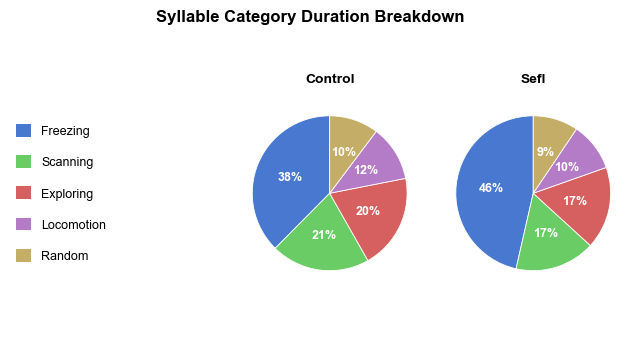

In [7]:
import importlib
import visualization
importlib.reload(visualization)
from visualization import *

cat_order = ['Freezing', 'Scanning', 'Exploring', 'Locomotion', 'Random']

plot_syllable_category_pie(
    kpms_data,
    condition_col='condition',
    category_col='behavior_category',
    duration_col='duration',
    category_order=cat_order,
    title_text='Syllable Category Duration Breakdown',
    output_filename='syllable_category_pie.svg',
)